# Day 5 - Supervised Learning Mini Project

## Introduction

In this notebook, I will build a complete supervised learning pipeline using the Healthcare Stroke Dataset.

The project includes data exploration, preprocessing, train/test splitting, model training, evaluation, baseline comparison, and model selection.

## Dataset

I used the Healthcare Stroke Dataset.

The target variable is `stroke`:

- 0 = No Stroke
- 1 = Stroke

Since the target contains two classes, this is a classification problem.

In [32]:
## Import Libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.dummy import DummyClassifier 
from sklearn.metrics import (
    accuracy_score ,
    precision_score ,
    f1_score,
    confusion_matrix ,
    classification_report 
)
from sklearn.metrics import recall_score

## Hands-On Lab : mini project 
## Step 1 : Choose a provided dataset and determine whether the task is regression or classification.

In [3]:
## Load Datasets 
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


DataSet Information:
I checked the dataset shape ,columns names ,data types , missing values , target distribution

In [4]:
print("shape",df.shape)
print()
print("columns")
print(df.columns)

shape (5110, 12)

columns
Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [6]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [37]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [38]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.698018,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.400000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### Observation

The numerical summary shows the mean, minimum, maximum, and quartile values of the numerical features.

The features have different value ranges, so scaling will be useful before training Logistic Regression.

### Observation

The duplicate check shows whether repeated patient records exist in the dataset.

## Target distribution 


In [7]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [ ]:
df["stroke"].value_counts(normalize=True) # Calculate the proportion of each class in the stroke column 

stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

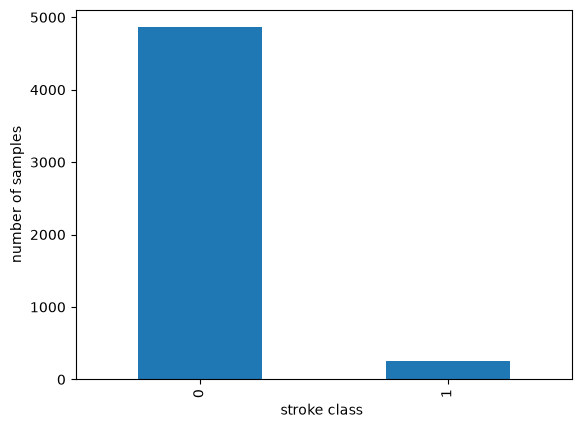

In [12]:
## Target plot 
df["stroke"].value_counts().plot(kind="bar")
plt.xlabel("stroke class ")
plt.ylabel("number of samples")
plt.show()

### observation
The dataset contains numerical values and categorical features 
- the bmi column contains missing values that must be handled before training 
- The target classes are imbalanced because the number of patients without stroke is much larger than the number of patients with stroke 
- for this reason ,accuracy alone may not be enough so recall and f1-score will also be used 


## Step 2: Data Preprocessing

Before training the models, the data needs to be prepared.

The preprocessing steps include:

- Handling missing values.
- Encoding categorical features.
- Splitting the data into training and testing sets.
- Scaling the numerical features.

### Remove the ID Column

The `id` column is removed because it only identifies each patient and does not provide useful information for stroke prediction.

In [36]:
bmi_mean = x_train["bmi"].mean()

x_train["bmi"] = x_train["bmi"].fillna(bmi_mean)
x_test["bmi"] = x_test["bmi"].fillna(bmi_mean)

### Observation

The missing BMI values were replaced using the mean calculated from the training data only.

The same training mean was applied to the test data to avoid data leakage.

In [14]:
df = pd.get_dummies(df, drop_first=True)

# observation 
Convert categorical columns into dummy variables and avoid redundancy

In [21]:
df.isnull().sum()

age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
stroke                            0
gender_Male                       0
gender_Other                      0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64

### Observation

All missing values were successfully handled 

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,5110.0,28.893237,7.698018,10.30,23.800,28.400,32.80,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


## Encode Categorical Features

Machine learning models require numerical inputs.

Therefore, categorical features are converted into numerical values using One-Hot Encoding.

In [ ]:
df = pd.get_dummies(df,drop_first =True)  # Convert categorical columns into numeric dummy variables

## Select Features and Target

The target variable is **stroke**, while all remaining columns are used as input features.

In [23]:
x =df.drop("stroke",axis =1 ) 
y = df["stroke"]

### Observation

The input features are stored in **X**, while the target variable **stroke** is stored in **y**.

The models will learn the relationship between the features and the target to predict whether a patient has a stroke.

## Train/Test Split

The dataset is divided into training and testing sets.

The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

In [25]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
print("X train shape:", x_train.shape)
print("X test shape:", x_test.shape)
print("y train shape:", y_train.shape)
print("y test shape:", y_test.shape)

X train shape: (4088, 16)
X test shape: (1022, 16)
y train shape: (4088,)
y test shape: (1022,)


### Observation

The dataset was divided into 80% training data and 20% testing data.

The **stratify** parameter preserves the class distribution in both sets

## Handle Missing Values

The mean BMI value is calculated from the training data only.

The same training mean is then used to fill missing BMI values in both the training and testing sets.

In [40]:
bmi_mean = x_train["bmi"].mean()

x_train = x_train.copy()
x_test = x_test.copy()

x_train["bmi"] = x_train["bmi"].fillna(bmi_mean)
x_test["bmi"] = x_test["bmi"].fillna(bmi_mean)

print("Training missing values:", x_train.isnull().sum().sum())
print("Testing missing values:", x_test.isnull().sum().sum())

Training missing values: 0
Testing missing values: 0


## Encode Categorical Features

Categorical columns are converted into numerical dummy variables because machine learning models require numerical input.

In [41]:
x_train_encoded = pd.get_dummies(
    x_train,
    drop_first=True
)

x_test_encoded = pd.get_dummies(
    x_test,
    drop_first=True
)

x_train_encoded, x_test_encoded = x_train_encoded.align(
    x_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoded training shape:", x_train_encoded.shape)
print("Encoded testing shape:", x_test_encoded.shape)

Encoded training shape: (4088, 16)
Encoded testing shape: (1022, 16)


## Feature Scaling

Feature scaling is applied using **StandardScaler**.

The scaler is fitted only on the training data to avoid data leakage.

In [31]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

The scaler was fitted only on the training set and then applied to the testing set